In [1]:
from nilearn.datasets import fetch_spm_multimodal_fmri

subject_data = fetch_spm_multimodal_fmri()

/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[get_dataset_dir] Dataset found in /Users/clairenastaskin/nilearn_data/spm_multimodal_fmri

In [2]:
# repetition time, in seconds
t_r = 2.0
# Sample at the beginning of each acquisition.
slice_time_ref = 0.0
# We use a discrete cosine transform to model signal drifts.
drift_model = "Cosine"
# The cutoff for the drift model is 0.01 Hz.
high_pass = 0.01
# The hemodynamic response function
hrf_model = "spm + derivative"

In [3]:
import warnings

from nilearn.image import concat_imgs, mean_img, resample_img

# Avoid getting too many warnings due to resampling
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fmri_img = [
        concat_imgs(subject_data.func1, auto_resample=True),
        concat_imgs(subject_data.func2, auto_resample=True),
    ]
affine, shape = fmri_img[0].affine, fmri_img[0].shape
print("Resampling the second image (this takes time)...")
fmri_img[1] = resample_img(
    fmri_img[1], affine, shape[:3], copy_header=True, force_resample=True
)

Resampling the second image (this takes time)...


In [4]:
print(f"fmri_img[0] shape: {fmri_img[0].shape}")
print(f"fmri_img[1] shape: {fmri_img[1].shape}")

fmri_img[0] shape: (64, 64, 32, 390)
fmri_img[1] shape: (64, 64, 32, 390)


In [5]:
mean_image = mean_img(fmri_img, copy_header=True)
print(f"Mean image shape: {mean_image.shape}")

Mean image shape: (64, 64, 32)


In [6]:
import numpy as np
import pandas as pd

from nilearn.glm.first_level import make_first_level_design_matrix

design_matrices = []

for idx, img in enumerate(fmri_img, start=1):
    # Build experimental paradigm
    n_scans = img.shape[-1]
    print(subject_data[f"events{idx}"])
    events = pd.read_table(subject_data[f"events{idx}"])
    # Define the sampling times for the design matrix
    frame_times = np.arange(n_scans) * t_r
    # Build design matrix with the reviously defined parameters
    design_matrix = make_first_level_design_matrix(
        frame_times,
        events,
        hrf_model=hrf_model,
        drift_model=drift_model,
        high_pass=high_pass,
    )
    # put the design matrices in a list
    design_matrices.append(design_matrix)
    
print(f"Number of design matrices: {len(design_matrices)}")
for i, dm in enumerate(design_matrices, 1):
    print(f"Design matrix {i} shape: {dm.shape}")

/Users/clairenastaskin/nilearn_data/spm_multimodal_fmri/sub001/fMRI/session1_events.tsv
/Users/clairenastaskin/nilearn_data/spm_multimodal_fmri/sub001/fMRI/session2_events.tsv
Number of design matrices: 2
Design matrix 1 shape: (390, 20)
Design matrix 2 shape: (390, 20)


In [7]:
# Print information about the structure of the design matrices
print("\nDesign matrix details:")
for i, dm in enumerate(design_matrices, 1):
    print(f"\nDesign Matrix {i}:")
    print("Columns:", dm.columns.tolist())
    print("Shape:", dm.shape)
    print("Column types:", dm.dtypes.value_counts())
    
    # Print some basic statistics
    print("\nSummary statistics:")
    print(dm.describe().round(2))



Design matrix details:

Design Matrix 1:
Columns: ['faces', 'faces_derivative', 'scrambled', 'scrambled_derivative', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'drift_6', 'drift_7', 'drift_8', 'drift_9', 'drift_10', 'drift_11', 'drift_12', 'drift_13', 'drift_14', 'drift_15', 'constant']
Shape: (390, 20)
Column types: float64    20
Name: count, dtype: int64

Summary statistics:
        faces  faces_derivative  scrambled  scrambled_derivative  drift_1  \
count  390.00            390.00     390.00                390.00   390.00   
mean     0.08             -0.00       0.11                 -0.00     0.00   
std      0.10              0.03       0.11                  0.04     0.05   
min     -0.03             -0.08      -0.04                 -0.08    -0.07   
25%     -0.00             -0.02      -0.00                 -0.03    -0.05   
50%      0.04              0.00       0.10                  0.00     0.00   
75%      0.16              0.01       0.19                  0.03    

/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_5677/2311891077.py:11: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrices[0], ax=axes[0])
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_5677/2311891077.py:13: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrices[1], ax=axes[1])
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_5677/2311891077.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


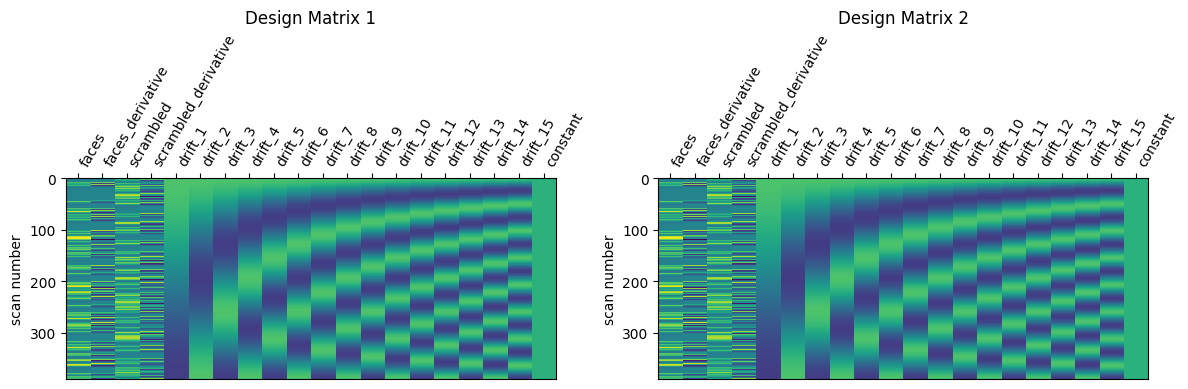

In [26]:
import matplotlib.pyplot as plt
from nilearn.plotting import plot_design_matrix


contrast_matrix = np.eye(design_matrix.shape[1])
basic_contrasts = {
    column: contrast_matrix[i]
    for i, column in enumerate(design_matrix.columns)
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_design_matrix(design_matrices[0], ax=axes[0])
axes[0].set_title('Design Matrix 1')
plot_design_matrix(design_matrices[1], ax=axes[1]) 
axes[1].set_title('Design Matrix 2')
plt.tight_layout()
fig.show()

In [27]:
from nilearn.glm.first_level import FirstLevelModel

print("Fitting a GLM")
fmri_glm = FirstLevelModel()
fmri_glm = fmri_glm.fit(fmri_img, design_matrices=design_matrices)

Fitting a GLM
